C:\Users\manas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\manas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\manas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\manas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

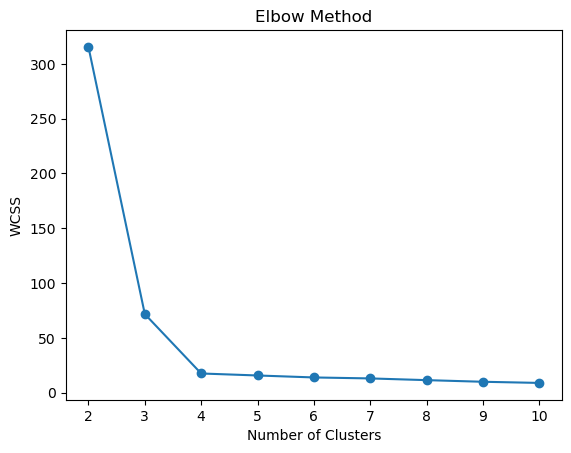

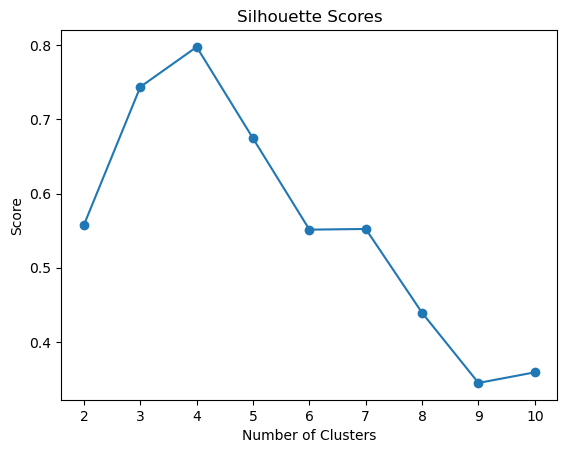

C:\Users\manas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


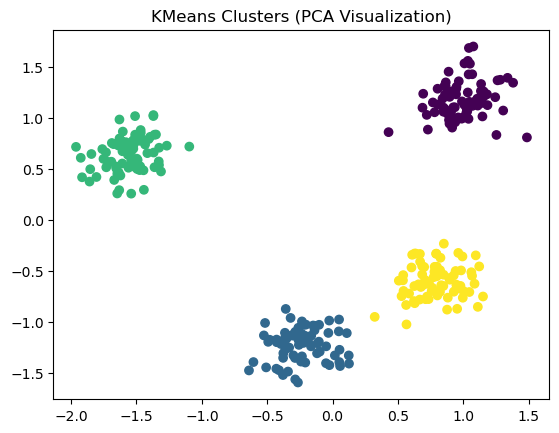

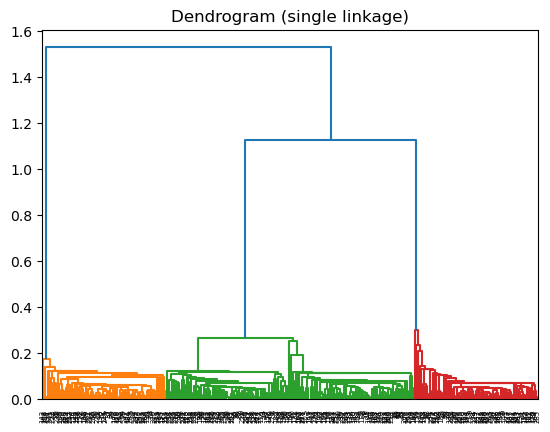

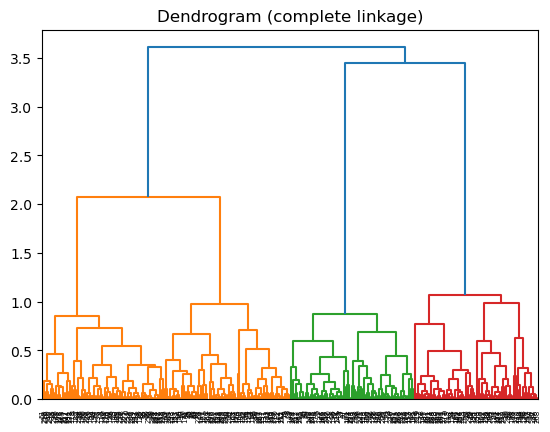

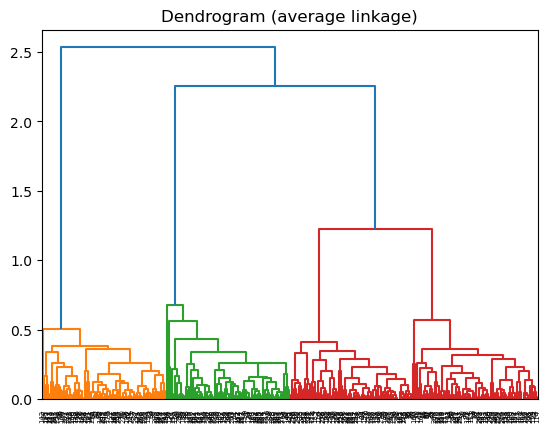

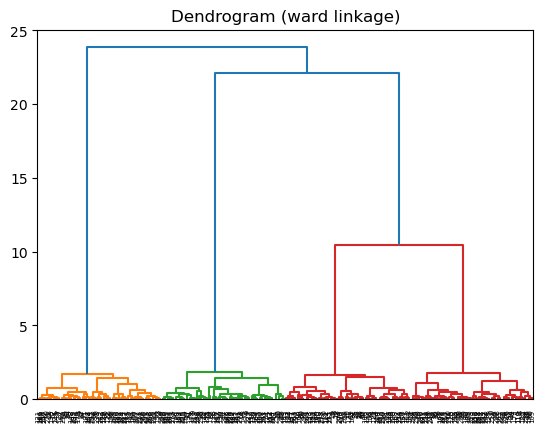

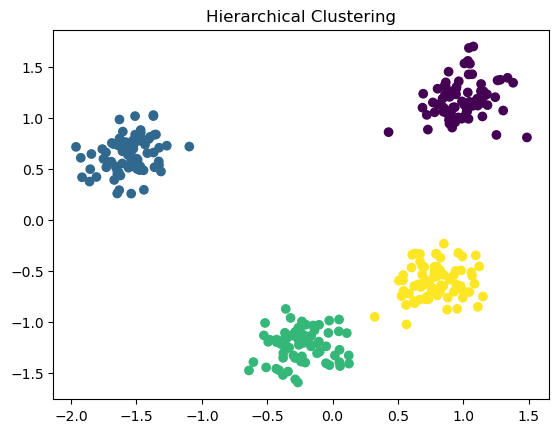

In [1]:
# EXPERIMENT 9 – KMEANS AND HIERARCHICAL CLUSTERING

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

# --------------------------------
# Generate Customer Dataset
# --------------------------------
X, y = make_blobs(n_samples=300, centers=4, random_state=42)

data = pd.DataFrame(X, columns=["Annual_Income","Spending_Score"])

# --------------------------------
# Feature Scaling
# --------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# --------------------------------
# K-MEANS CLUSTERING
# --------------------------------

wcss = []
sil_scores = []

for k in range(2,11):

    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Elbow Method
plt.plot(range(2,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# Silhouette Score Plot
plt.plot(range(2,11), sil_scores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.show()

# Apply optimal k
kmeans = KMeans(n_clusters=4)
labels = kmeans.fit_predict(X_scaled)

# PCA for Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("KMeans Clusters (PCA Visualization)")
plt.show()


# --------------------------------
# HIERARCHICAL CLUSTERING
# --------------------------------

linkage_methods = ['single','complete','average','ward']

for method in linkage_methods:

    Z = linkage(X_scaled, method=method)

    plt.figure()
    dendrogram(Z)
    plt.title(f"Dendrogram ({method} linkage)")
    plt.show()

# Agglomerative clustering
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
clusters = agg.fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("Hierarchical Clustering")
plt.show()